In [1]:
# [설정] 작업 경로를 프로젝트 루트(ess-battery-project)로 맞춘다.
# notebooks/ 안에서 열어도 이후 모든 경로(results/, reports/ ...)가 루트 기준으로 동작한다.
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "src" / "features.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("ess-battery-project 루트를 찾지 못했습니다. 노트북을 프로젝트 안에서 여세요.")
    ROOT = ROOT.parent
os.chdir(ROOT)
for p in (ROOT / "src", ROOT / "src" / "eda"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import json

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import plot_style as ps        # src/plot_style.py — 한글 폰트 · 배치 색
import train as tr             # src/train.py — 상수·지표 함수만 사용 (어떤 단계도 실행하지 않음)

%matplotlib inline
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 200)
RES = ROOT / "results"
# 이 노트북은 저장된 결과만 읽는다. Test(Batch 2)·Batch 3는 이미 1회 실행되었다.
assert (RES / ".test_done").exists() and (RES / ".batch3_done").exists(), "Test/Batch 3 완료 표식이 없습니다"
SEL = json.loads((RES / "selection.json").read_text())
VAL = json.loads((RES / "valid.json").read_text())
TEST = json.loads((RES / "test.json").read_text())
B3 = json.loads((RES / "batch3.json").read_text())
CV = pd.read_csv(RES / "cv_results.csv")
PRED = {k: pd.read_csv(RES / f"{k}_predictions.csv") for k in ("valid", "test", "batch3")}
M1P = {k: v[v["model"] == "M1"] for k, v in PRED.items()}
BLUE, GRAY, INK = ps.BATCH_COLOR["batch1"], "#94A3B8", "#0B1220"

print("Test 1회 실행 기록 :", (RES / ".test_done").read_text().splitlines()[-1])
print("선택 모델          :", SEL["selected"]["id"], "—", SEL["selected"]["name"], SEL["selected"]["params"])

Test 1회 실행 기록 : completed	2026-10-01T16:04:30	selection_sha256=0987c11fa34c10b9b25e58b12334fce93ceab9fae8494b7c03053e8f1f226a20	forced=False
선택 모델          : M1 — StandardScaler → Ridge (dQ_logvar + Qcc_init) {'model__alpha': 0.0001}


# 03. 모델링 — 선택, 검증, 테스트 결과 읽기

**이 노트북의 목적**
- DAY 1 전략대로 만든 파이프라인(`src/train.py`)의 결과를 순서대로 읽는다.
- 노션 Performance Reporting 형식으로 성능을 정리하고, Gap을 해석한다.

**중요 — 이 노트북은 모델을 다시 학습하거나 평가하지 않는다**
- Batch 2 테스트와 Batch 3 추가 검증은 이미 **딱 1회** 실행했다(`results/.test_done`, `.batch3_done`).
- 여기서는 저장된 결과 파일만 읽는다.
- 저장된 셀별 예측값으로 MAPE를 다시 계산해, 보고한 숫자와 같은지만 확인한다.

**흐름**
1. 데이터 분할 → 2. 후보 모델 비교와 선택 → 3. 성능 표(노션 형식)와 Gap 해석 → 4. 예측 vs 실제 → 5. 오류 분석 → 6. Batch 3 → 7. 사전 가설 점검 → 8. 실행 기록 공개, ESS 해석·한계

## 1. 데이터 분할 — 왜 정책 단위로 나눴나

**질문** 학습·검증 셀을 어떻게 나눠야 누수 없이 성능을 잴 수 있는가?

**방법**
- EDA Q4에서 충전 정책이 수명 차이의 대부분을 설명했다. 같은 정책 셀이 학습과 검증에 나뉘면 정책 평균이 새어 들어간다.
- 그래서 노션의 Hold-out 사유(셀 단위 분리)를 **정책 단위 분리**로 강화했다.
  - **Valid (Hold-out)**: Batch 1의 9셀·5정책. 교차검증보다 먼저 고정했다(`results/holdout_cells.csv`).
  - **Train (CV)**: 나머지 27셀·15정책.
  - 교차검증은 정책 단위 GroupKFold(5)를 seed만 바꿔 20번 반복한다.
  - **Test**: 선택한 설정으로 Batch 1 라벨 셀 전체(36셀)를 다시 학습한 뒤, Batch 2에 한 번만 적용한다.

In [2]:
F = pd.read_csv(RES / "features.csv")
B1 = F[(F["batch"] == "batch1") & F["labeled"]]
tr_df = B1[B1["cell_key"].isin(SEL["data"]["train_cells"])]
ho_df = B1[B1["cell_key"].isin(SEL["data"]["holdout_cells"])]


def life_range(s):
    return f"{s.min():,.0f} ~ {s.max():,.0f}"


split = pd.DataFrame([
    {"구분": "Train (Batch 1 CV)", "셀": len(tr_df), "정책": tr_df["policy"].nunique(),
     "수명 범위": life_range(tr_df["cycle_life"]), "쓰임": "정책 단위 GroupKFold(5) × 20회, 모델 선택"},
    {"구분": "Valid (Batch 1 Hold-out)", "셀": len(ho_df), "정책": ho_df["policy"].nunique(),
     "수명 범위": life_range(ho_df["cycle_life"]), "쓰임": "선택 뒤 확인만 (선택을 바꾸지 않음)"},
    {"구분": "Test (Batch 2)", "셀": len(M1P["test"]), "정책": M1P["test"]["policy"].nunique(),
     "수명 범위": life_range(M1P["test"]["true"]), "쓰임": "Batch 1 36셀 재학습 후 1회 평가"},
    {"구분": "Test (Batch 3, 선택)", "셀": len(M1P["batch3"]), "정책": M1P["batch3"]["policy"].nunique(),
     "수명 범위": life_range(M1P["batch3"]["true"]), "쓰임": "같은 고정 모델로 1회 평가"},
]).set_index("구분")
display(split)
print("Train과 Valid가 공유하는 정책 수:", len(set(tr_df["policy"]) & set(ho_df["policy"])))

,셀,정책,수명 범위,쓰임
구분,,,,
Train (Batch 1 CV),27,15,"534 ~ 1,074","정책 단위 GroupKFold(5) × 20회, 모델 선택"
Valid (Batch 1 Hold-out),9,5,"599 ~ 1,014",선택 뒤 확인만 (선택을 바꾸지 않음)
Test (Batch 2),39,12,"392 ~ 1,186",Batch 1 36셀 재학습 후 1회 평가
"Test (Batch 3, 선택)",44,8,"541 ~ 1,935",같은 고정 모델로 1회 평가


Train과 Valid가 공유하는 정책 수: 0


**결과·해석**
- Train과 Valid는 충전 정책이 하나도 겹치지 않는다. 정책 평균 수명이 새어 들어갈 길이 없다.
- Valid 9셀은 수명순 5층에서 층마다 1정책씩, 양 끝 정책은 빼고 CV보다 먼저 뽑았다(수명 599\~1,014).
- Test 셀의 수명 범위는 학습 범위와 크게 다르다. 이것이 이후 Gap의 출발점이다.

---
## 2. 후보 모델 비교와 선택

**질문** 어떤 모델을 최종으로 고를 것인가? 선택 기준은 테스트 전에 정해 두었는가?

**방법** (DAY 1에 고정한 규칙)
- 후보는 단순한 순서로 둔다: M0 OLS(ΔQ 깊이만) < M1 Ridge(ΔQ 깊이 + 초기 용량) < M2 Elastic Net(10개) < M3 GPR < M4 RF·GBR.
- ① Train 교차검증 MAPE 평균이 가장 낮은 모델을 기준으로 잡는다.
- ② 기준 + 1 SE(표준오차) 안에 드는 모델 중 **가장 단순한 모델**을 고른다. 셀이 적을 때 작은 차이를 믿지 않기 위해서다.
- ③ 외삽 게이트: 학습 범위보다 오래 산 Batch 1 중도절단 셀 5개 중 3개 이상에서 '수명 하한'보다 짧게 예측하면 탈락이다.
- 하이퍼파라미터는 바깥 fold 안에서 다시 교차검증(nested CV)으로 정한다. Valid 값은 선택에 쓰지 않는다.

,선택,Train CV MAPE,SD,SE,1SE 이내,게이트 위반(#00~04),게이트 통과
M0 OLS · ΔQ 깊이,,9.967,3.014,1.326,False,1/5,True
M1 Ridge · ΔQ 깊이 + 초기 용량,◀ 선택,6.851,1.975,0.922,True,0/5,True
M2 Elastic Net · 10개,,9.407,2.924,1.284,False,1/5,True
M3 GPR · 2개,,7.036,1.913,0.894,True,0/5,True
M4 RF · 2개,,10.628,3.647,1.725,False,5/5,False
M4 GBR · 2개,,9.488,3.485,1.622,False,5/5,False


① 최저 평균 = M1 6.85%   ② 임계 = 최저 + 1 SE = 7.77%   ③ 임계 안 · 게이트 통과 = ['M1', 'M3']   → 가장 단순한 M1
최종 M1 (Batch 1 36셀 재학습) 원단위 계수: ΔQ 깊이 -0.328 log10/단위, 초기 용량 +3.30 log10/Ah (+10 mAh → 수명 ×1.08)


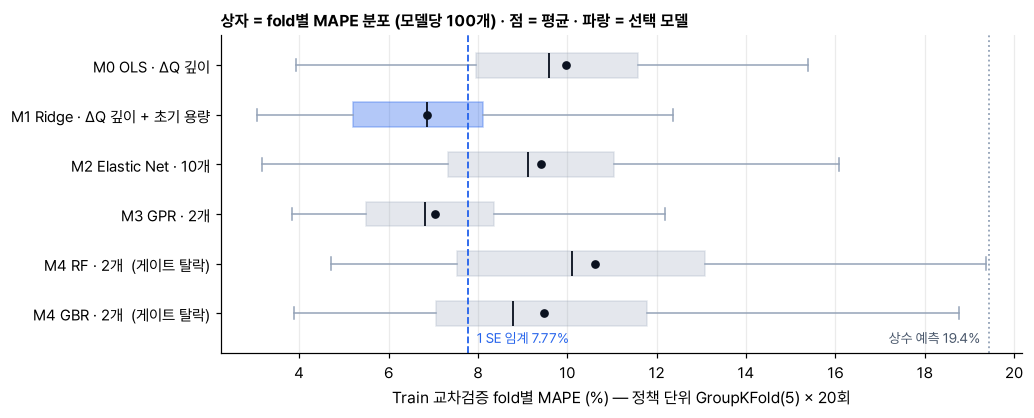

In [3]:
NAMES = {"M0": "M0 OLS · ΔQ 깊이", "M1": "M1 Ridge · ΔQ 깊이 + 초기 용량", "M2": "M2 Elastic Net · 10개",
         "M3": "M3 GPR · 2개", "M4_RF": "M4 RF · 2개", "M4_GBR": "M4 GBR · 2개"}
ids = list(NAMES)
cand = pd.read_csv(RES / "model_candidates.csv").set_index("model")
tbl = cand.loc[ids, ["Train CV MAPE", "SD", "SE", "1SE 이내", "게이트 위반(#00~04)", "게이트 통과"]]
tbl.index = [NAMES[m] for m in ids]
tbl.insert(0, "선택", ["◀ 선택" if m == SEL["selected"]["id"] else "" for m in ids])
display(tbl)

rule = SEL["rule"]["primary"]
print(f"① 최저 평균 = {rule['best']} {rule['best_mean']:.2f}%   ② 임계 = 최저 + 1 SE = {rule['threshold']:.2f}%   "
      f"③ 임계 안 · 게이트 통과 = {rule['within_1se_eligible']}   → 가장 단순한 {SEL['selected']['id']}")
cf = TEST["selected"]["coefs_raw_fit36"]
print(f"최종 M1 (Batch 1 36셀 재학습) 원단위 계수: ΔQ 깊이 {cf['dQ_logvar']:+.3f} log10/단위, "
      f"초기 용량 {cf['Qcc_init']:+.2f} log10/Ah (+10 mAh → 수명 ×{10 ** (cf['Qcc_init'] * 0.01):.2f})")

fig, ax = plt.subplots(figsize=(9.5, 3.9))
data = [CV.loc[CV["model"] == m, "mape"].to_numpy() for m in ids]
bp = ax.boxplot(data, orientation="horizontal", widths=0.5, patch_artist=True, showfliers=False,
                medianprops=dict(color=INK, lw=1.2), whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY))
for box, m in zip(bp["boxes"], ids):
    box.set(facecolor=(BLUE if m == "M1" else GRAY), alpha=0.35 if m == "M1" else 0.25,
            edgecolor=BLUE if m == "M1" else GRAY)
ax.scatter([d.mean() for d in data], range(1, len(ids) + 1), color=INK, s=22, zorder=3)
ax.axvline(rule["threshold"], color=BLUE, ls="--", lw=1.2)
ax.text(rule["threshold"] + 0.2, len(ids) + 0.5, f"1 SE 임계 {rule['threshold']:.2f}%", color=BLUE, fontsize=9, va="center")
c0 = CV.loc[CV["model"] == "C0", "mape"].mean()
ax.axvline(c0, color=GRAY, ls=":", lw=1.2)
ax.text(c0 - 0.2, len(ids) + 0.5, f"상수 예측 {c0:.1f}%", color="#475569", fontsize=9, va="center", ha="right")
ax.set_yticks(range(1, len(ids) + 1), [NAMES[m] + ("  (게이트 탈락)" if m.startswith("M4") else "") for m in ids])
ax.set_ylim(len(ids) + 0.8, 0.4)                       # 위 = M0, 아래 여백에 기준선 이름
ax.set_xlabel("Train 교차검증 fold별 MAPE (%) — 정책 단위 GroupKFold(5) × 20회")
ax.grid(axis="y", visible=False)
ax.set_title("상자 = fold별 MAPE 분포 (모델당 100개) · 점 = 평균 · 파랑 = 선택 모델", loc="left", fontsize=10.5)
fig.tight_layout()
plt.show()

**결과**
- Train 교차검증 평균이 가장 낮은 모델은 M1이다.
- 1 SE 임계 안에는 M1과 M3(GPR)이 들어왔고, 둘 다 게이트를 통과했다.
- 규칙대로 더 단순한 **M1 Ridge**를 골랐다. 최종 alpha는 탐색 범위의 하한(1e-4)이라, 사실상 규제가 없는 선형회귀(OLS)와 같다.
- 두 피처가 서로 거의 독립이라(VIF ≈ 1, 02 노트북) 규제가 할 일이 없었다. 작은 데이터에 맞춘 것은 규제가 아니라 피처 수(2개)다.
- 트리 모델(M4)은 학습 범위 밖을 예측하지 못해 게이트에서 탈락했다.

**해석·시사점**
- 초기 용량을 더한 효과가 교차검증에서 1 SE를 넘었다(M0 9.97% → M1 6.85%). DAY 1의 '후보'가 규칙에 따라 채택됐다.
- GPR(M3)은 성능이 비슷하지만 더 복잡하다. 36셀에서 복잡도를 늘릴 근거가 없다.
- 노션 Qdlin 경고 때문에, 선택되지 않은 M0도 이후 모든 표에 함께 싣는다.

---
## 3. 성능 결과 — 노션 Reporting format

**질문** 선택한 M1은 Train·Valid·Test에서 얼마나 맞히는가? 원논문 목표 9.1%와는 얼마나 차이 나는가?

**방법**
- 노션 형식 그대로 6행 표를 만든다. 숫자는 `results/model_performance.csv`(report 단계 산출물)에서 읽는다.
- 비고는 읽기 쉽게 줄였다. 전체 비고는 CSV에 있다.
- 저장된 셀별 예측값으로 MAPE를 다시 계산해, 표의 숫자와 같은지 확인한다.
- Gap 부호는 노션 비고의 (+) 뜻이 유지되도록 정했다.
  - Gap(Train-Valid) = Valid − Train
  - Gap(Valid-Test) = Test − Valid
  - Gap(Target-Test) = Test − 9.1

In [4]:
def short_notes(model):
    key = "selected" if model == "M1" else "M0"
    cvs = next(r for r in SEL["cv_summary"] if r["model"] == model)
    v, t = VAL[key], TEST[key]
    return {"Train (Batch 1 CV)": f"정책 단위 GroupKFold(5)×20 nested 평균 (±SD {cvs['sd']:.2f})",
            "Valid (Batch 1 Hold-out)": f"9셀·5정책 고정 분할, 95% CI [{v['ci95'][0]:.2f}, {v['ci95'][1]:.2f}]",
            "Test (Batch 2)": f"39셀 1회, 과대예측 {t['n_over']}/{t['n']}, 평균 부호오차 {t['signed_mean_pct']:+.1f}%"}


def notion_view(csv_name, model):
    t = pd.read_csv(RES / csv_name, dtype=str).set_index("구분")
    notes = short_notes(model)
    t["비고"] = [notes.get(k, v) for k, v in t["비고"].items()]
    return t


def mape_of(df, model):
    d = df[df["model"] == model]
    return tr.mape_pct(d["true"], d["pred"])


display(Markdown("**선택 모델 M1** — Ridge(alpha=1e-4) · [ΔQ 깊이, 초기 용량] · log10 타깃"))
display(notion_view("model_performance.csv", "M1"))
display(Markdown("**M0 병기** — OLS · [ΔQ 깊이] (노션 Qdlin 경고 대응, 선택과 무관하게 항상 표시)"))
display(notion_view("model_performance_M0.csv", "M0"))

# 저장된 예측값으로 다시 계산 → 표 값과 비교 (모델을 다시 돌리지 않음)
rows = ["Train (Batch 1 CV)", "Valid (Batch 1 Hold-out)", "Test (Batch 2)"]
recalc = pd.DataFrame({m: [CV.loc[CV["model"] == m, "mape"].mean(), mape_of(PRED["valid"], m), mape_of(PRED["test"], m)]
                       for m in ("M1", "M0")}, index=rows)
shown = pd.DataFrame({m: pd.read_csv(RES / f, index_col="구분")["MAPE (%)"].astype(float).loc[rows]
                      for m, f in (("M1", "model_performance.csv"), ("M0", "model_performance_M0.csv"))})
print(f"저장 예측값으로 다시 계산한 MAPE와 표 값의 최대 차이: {(recalc.round(2) - shown).abs().max().max():.3f}")

**선택 모델 M1** — Ridge(alpha=1e-4) · [ΔQ 깊이, 초기 용량] · log10 타깃

,MAPE (%),비고
구분,,
Train (Batch 1 CV),6.85,정책 단위 GroupKFold(5)×20 nested 평균 (±SD 1.97)
Valid (Batch 1 Hold-out),6.31,"9셀·5정책 고정 분할, 95% CI [3.47, 9.91]"
Test (Batch 2),20.48,"39셀 1회, 과대예측 35/39, 평균 부호오차 +19.3%"
Gap (Train-Valid),-0.54,(+) : 과적합 의심
Gap (Valid-Test),+14.17,(+) : 배치간 일반화 저하 의심
Gap (Target-Test),+11.38,Target : 원논문 9.1%


**M0 병기** — OLS · [ΔQ 깊이] (노션 Qdlin 경고 대응, 선택과 무관하게 항상 표시)

,MAPE (%),비고
구분,,
Train (Batch 1 CV),9.97,정책 단위 GroupKFold(5)×20 nested 평균 (±SD 3.01)
Valid (Batch 1 Hold-out),6.31,"9셀·5정책 고정 분할, 95% CI [3.87, 8.97]"
Test (Batch 2),28.56,"39셀 1회, 과대예측 38/39, 평균 부호오차 +28.1%"
Gap (Train-Valid),-3.65,(+) : 과적합 의심
Gap (Valid-Test),+22.25,(+) : 배치간 일반화 저하 의심
Gap (Target-Test),+19.46,Target : 원논문 9.1%


저장 예측값으로 다시 계산한 MAPE와 표 값의 최대 차이: 0.000


**결과**
- Train과 Valid는 원논문 목표(9.1%)보다 좋다.
- Batch 2 Test는 20.48%로 목표에 미달한다.
- M0(ΔQ 깊이만)의 Test는 28.56%다. 초기 용량을 더한 M1이 Batch 2 오차를 약 8%p 줄였다.

### Gap 해석 — 내 말로 정리

**Gap (Train-Valid) = −0.54 → 과적합 신호가 아니다**
- 노션 기준으로 (+)면 과적합 의심인데, 오히려 Valid가 조금 더 좋다.
- Valid는 셀이 9개뿐이라 신뢰구간이 넓다. Train 평균은 그 구간 안에 있다.
- Valid가 오히려 조금 좋은 이유: Hold-out은 설계 단계에서 수명순 양 끝 정책을 넣지 않았다(DAY 1 §11). Valid 수명은 599\~1,014이고, 학습 라벨의 양 끝(534, 1,074)은 Train에 있다.
- M0와 M1의 Valid가 둘 다 6.31인 것은 우연이다(M0 6.313, M1 6.310). 9셀로는 두 모델을 가를 수 없다.
- 그래서 결론은 "Batch 1 안에서는 처음 보는 정책에도 성능이 유지된다"까지다. 9셀로 'Valid가 더 좋다'고 주장하지는 않는다.

**Gap (Valid-Test) = +14.17 → 배치가 바뀌자 '한 방향으로' 틀렸다**
- 같은 모델의 오차가 Batch 1 안 6%대에서 Batch 2 20%대로 커졌다.
- 핵심은 오차의 방향이다. 39셀 중 35셀을 실제보다 길게 예측했다.
- 무작위 오차라면 위아래가 섞여야 한다. 한쪽으로 몰렸다는 것은 **Batch 2 셀이 같은 피처 값에서도 Batch 1보다 짧게 산다**는 뜻이다.
- 같은 ΔQ 깊이에서 Batch 2 fastcharge가 약 24% 짧다는 위험은 테스트 전 EDA(DAY 1 보고서 §6 Q5, 수명비 0.76)에서 이미 보였다.
- 사후 분석(라벨 사용, 보고 성능 아님): 예측을 셀 공통 배율 하나(×1.20)로 나누면 MAPE가 20.48 → 9.87%로 준다. 이 Gap의 약 3/4이 셀 공통 치우침이다.
- 후보 6개 모두 Batch 2에서 19.5\~29.4%였다. 모델 종류를 바꿔서 생긴 Gap은 아니다.
- Batch 2에만 있는 시험 이력: 라벨 39셀 모두 ΔQ 측정 구간(cycle 10→100) 안에 약 66시간 기록 공백이 있고(테스트 뒤 원본 시간 기록에서 찾음), 직후 용량이 대부분 떨어졌다가(29/39셀이 −3 mAh 이하) 33/39셀이 다시 오른다(Batch 1·3 라벨 셀에는 없음, 5절 표). 모든 Batch 2 셀에 있어 비교군이 없으므로 원인 후보로만 둔다(로트·시험 시기도 후보).
- Train-Valid Gap이 작으므로 "모델이 Batch 1을 외웠다"기보다 "Batch 1에서 배운 관계가 Batch 2에서 어긋났다"로 읽는다.

**Gap (Target-Test) = +11.38 → 원논문 9.1%에 미달. 다만 비교 조건이 다르다**
- (아래 원논문 사실은 테스트 뒤 원저자 공개 코드와 논문 Table 1에서 확인했다.) 원논문은 9.1%의 계산식을 적지 않았다. Table 1 Full 모델의 같은 시기 테스트 7.5%(42셀)와 나중 배치 테스트 10.7%(40셀)를 셀 수로 평균하면 9.06%라, 두 값을 합친 것으로 보인다.
- 원논문은 우리 Batch 2(2018-02-20)를 테스트하지 않았다. 조건별로 나누면 같은 시기 7.5% vs Hold-out 6.31%, 나중 배치(2018-04-12 = Batch 3) 10.7% vs 같은 40셀 10.77%이고, Batch 2에는 원논문 대응 값이 없다.
- 원논문 1차 테스트는 셀을 번갈아 나눠, 같은 충전 정책 셀이 학습과 테스트 양쪽에 있다(Batch 1 부분만 봐도 21셀 중 19셀, `results/error_analysis.json`). 정책째 뗀 우리 Hold-out이 더 엄격한 조건이다.
- 노션은 'Batch 1/2는 유사'라고 했지만, 받은 Batch 2의 fastcharge 30셀은 모두 학습 최저 수명(534)보다 짧다. 학습 라벨 범위 밖을 맞혀야 하는 테스트다.
- 그래서 이 Gap을 '모델이 원논문보다 나쁘다'보다 '원논문에 대응 값이 없는 배치로 바뀐 비용'으로 읽는다.
- Batch 2로 튜닝해 Gap을 줄이는 것은 테스트 누수라서 하지 않았다.

---
## 4. 예측 vs 실제 — 어디서 어떻게 틀렸나

**질문** 오차는 수명 구간별로 고르게 퍼졌는가, 특정 그룹에 몰렸는가?

**방법**
- 저장된 셀별 예측(`results/*_predictions.csv`)으로 예측 vs 실제를 그린다. 두 축 모두 로그 축이다.
- 대각선 위 = 길게 예측(과대예측), 아래 = 짧게 예측(과소예측). 회색 띠는 ±10%다.
- 속이 빈 회색 점은 같은 셀의 M0(ΔQ 깊이만) 예측이다. 점선은 학습 수명 범위의 양 끝이다.

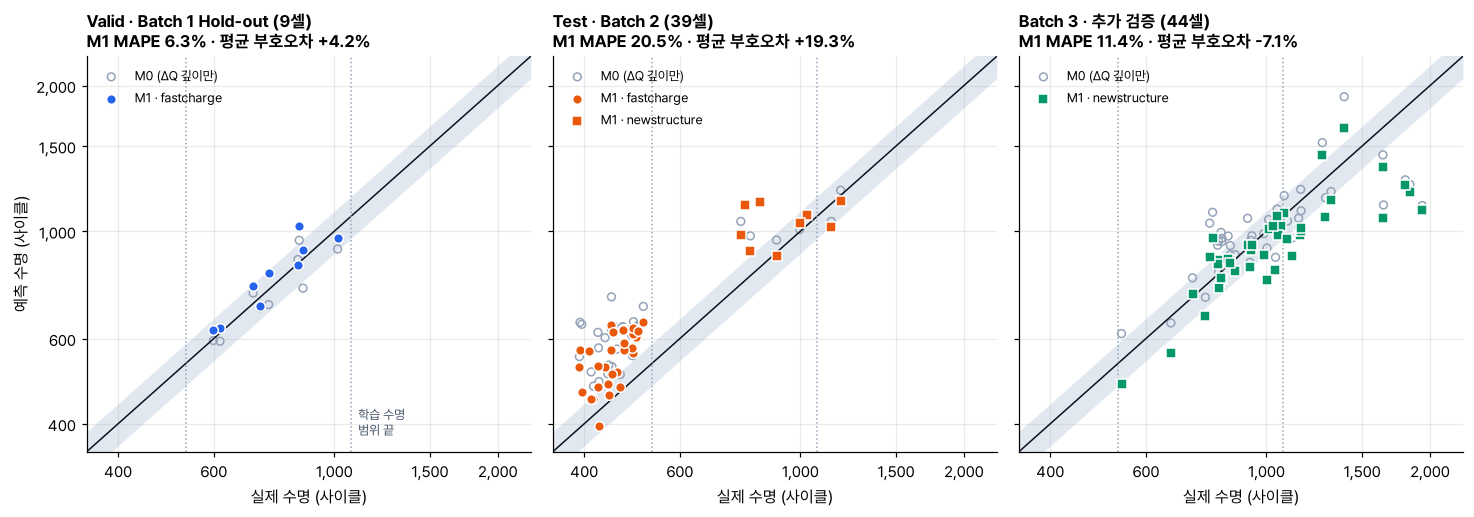

In [5]:
panels = [("valid", "Valid · Batch 1 Hold-out", "batch1"), ("test", "Test · Batch 2", "batch2"),
          ("batch3", "Batch 3 · 추가 검증", "batch3")]
lim, ticks = (350, 2300), [400, 600, 1000, 1500, 2000]
grid = np.geomspace(*lim, 60)
train_lo, train_hi = SEL["data"]["train_life_range"]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.8), sharex=True, sharey=True)
for ax, (key, title, b) in zip(axes, panels):
    d1, d0 = M1P[key], PRED[key][PRED[key]["model"] == "M0"]
    ax.fill_between(grid, grid * 0.9, grid * 1.1, color="#E2E8F0", lw=0)
    ax.plot(grid, grid, color=INK, lw=1)
    for xv in (train_lo, train_hi):
        ax.axvline(xv, color=GRAY, ls=":", lw=1)
    ax.scatter(d0["true"], d0["pred"], s=26, facecolor="none", edgecolor=GRAY, linewidth=1, label="M0 (ΔQ 깊이만)")
    for grp, mk in (("fastcharge", "o"), ("newstructure", "s")):
        g = d1[d1["group"] == grp]
        if len(g):
            ax.scatter(g["true"], g["pred"], s=40, marker=mk, color=ps.BATCH_COLOR[b], edgecolor="white",
                       linewidth=1, zorder=3, label=f"M1 · {grp}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xticks(ticks, [f"{t:,}" for t in ticks])
    ax.set_yticks(ticks, [f"{t:,}" for t in ticks])
    ax.minorticks_off()
    ax.set_title(f"{title} ({len(d1)}셀)\nM1 MAPE {tr.mape_pct(d1['true'], d1['pred']):.1f}% · "
                 f"평균 부호오차 {d1['signed_pct'].mean():+.1f}%", loc="left", fontsize=11)
    ax.set_xlabel("실제 수명 (사이클)")
    ax.legend(loc="upper left", fontsize=8.5)
axes[0].set_ylabel("예측 수명 (사이클)")
axes[0].text(train_hi * 1.03, 380, "학습 수명\n범위 끝", fontsize=8.5, color="#475569")
fig.tight_layout()
plt.show()

**결과**
- Valid: 점들이 대각선 가까이에 고르게 있다.
- Batch 2: 거의 모든 점이 대각선 위에 있다. 고속충전(●) 셀의 400대 수명을 600 안팎으로 예측한 경우가 많다.
- Batch 3: 학습 범위 안의 셀은 대체로 맞는다. 1,500 이상 긴 셀은 짧게 예측한다(대각선 아래).
- 회색 빈 점(M0)은 Batch 2에서 M1보다 더 위에 있다. 초기 용량이 과대예측을 일부 줄였다.

**해석·시사점**
- Batch 2의 오차는 '흩어짐'보다 '한쪽으로 밀림'이다. 셀별 처방보다 배치 수준의 원인을 찾아야 한다.
- Batch 3의 오차는 주로 학습 범위 밖의 긴 셀에서 나온다. 선형 모델로 외삽해도, 범위 밖에서는 정확도가 떨어진다.

---
## 5. 오류 분석 — 가장 크게 틀린 셀의 공통점

**질문** 모델이 가장 크게 틀린 셀들은 무엇이 같은가? 원인은 무엇으로 추정되는가?

**방법**
- Batch 2 그룹별 성능과, ΔQ 깊이 학습 범위 안/밖 성능을 나눠 본다.
- 오차가 가장 큰 10셀의 정책과 피처를 본다(README 오류 분석과 같은 기준).
- Batch 2 기록 공백 점검 결과(`src/check_rest_gap.py`, 원본 .mat 시간 기록, 공백 검출은 라벨 미사용·테스트 뒤 작성)를 함께 본다.
- 초기 용량의 배치 이동이 예측을 얼마나 움직였는지, 테스트 전에 정한 방식(계수 × 라벨 없는 이동량)으로 분해한다.
- 모두 저장된 예측의 사후 분석이다. 모델과 보고 숫자는 바뀌지 않는다.

In [6]:
detail = pd.read_csv(RES / "model_performance_test_detail.csv")
cols = {"n": "셀", "mape": "MAPE", "signed_mean_pct": "평균 부호오차 %", "over_ratio": "과대예측 비율",
        "n_out_of_range": "학습 범위 밖 셀", "mape_in_range": "범위 안 MAPE", "mape_out_of_range": "범위 밖 MAPE"}
d2 = detail[detail["batch"] == "batch2"].set_index(["model", "group"])[list(cols)].rename(columns=cols)
display(Markdown("**Batch 2 그룹별 성능** (M1 / M0)"))
display(d2.round(2))

worst = M1P["test"].sort_values("ape", ascending=False).head(10)
display(Markdown("**M1 오차 상위 10셀** (signed_pct + = 길게 예측)"))
display(worst[["cell_key", "group", "policy", "true", "pred", "signed_pct", "dQ_logvar", "out_of_train_range"]]
        .set_index("cell_key").round({"pred": 0, "signed_pct": 1, "dQ_logvar": 2}))

qd = TEST["selected"]["qcc_shift_decomposition"]["groups"]
decomp = pd.DataFrame({g: {"초기 용량 이동 (mAh, 라벨 없음)": v["shift_mAh"],
                           "① 계수 × 이동 → 예측 배율": v["pred_factor"],
                           "② 관측된 평균 배율 (예측/실제)": v["observed_factor"],
                           "③ 설명 안 된 나머지 = ② ÷ ①": 10 ** v["remainder_log10"]} for g, v in qd.items()}).T
display(Markdown("**초기 용량 이동 분해** (Batch 2, M1)"))
display(decomp.round(3))

gap = json.loads((RES / "rest_gap_summary.json").read_text())   # src/check_rest_gap.py 결과
gs = gap["라벨 셀 요약"]
gap_tbl = pd.DataFrame({b: {"라벨 셀": v["n_labeled"], "ΔQ 구간 안 24시간 넘는 단일 공백": v["n_single_long_gap_in_window"],
                            "공백 길이 (시간)": "~".join(map(str, v.get("gap_hours_range", ["-"]))),
                            "공백 전후 용량 변화 중앙값 (mAh)": v.get("qd_change_mAh_median", "-"),
                            "−3 mAh 이하로 떨어진 셀": v.get("n_qd_change_le_-3mAh", "-"),
                            "cycle 100까지 다시 오른 셀": v.get("n_recovered_by_cycle100", "-")} for b, v in gs.items()}).T
display(Markdown("**Batch 2 기록 공백 점검** (ΔQ 측정 구간 cycle 10→100, 라벨 미사용)"))
display(gap_tbl)
print("공백 위치:", {g: v["gap_cycle_range"] for g, v in gs["batch2"]["by_group"].items()},
      "| 사후 순위상관(용량 변화 vs M1 부호 오차):", gap["사후_오차와의_관계"]["batch2 전체"]["spearman_rho"])

bc = TEST["selected"]["breakin_check"]["by_group"]["fastcharge"]
ov = TEST["selected"]["breakin_check"]["overall"]
print(f"(H1 사전 점검, 39셀) 로그 잔차 vs 정점 사이클 Spearman ρ: CC 끝점(주) {ov['rho_cc_breakin_peak_cycle']:+.2f} (p {ov['p_cc_breakin_peak_cycle']:.2f}), "
      f"요약 용량(보조) {ov['rho_qd_breakin_peak_cycle']:+.2f} (p {ov['p_qd_breakin_peak_cycle']:.3f}) | 상승폭 {ov['rho_cc_breakin']:+.2f} (p {ov['p_cc_breakin']:.2f})")
print(f"(사전 지정 밖 탐색) fastcharge 30셀: 로그 잔차 vs 초기 용량 상승폭 Spearman ρ = {bc['rho_cc_breakin']:+.2f}")

**Batch 2 그룹별 성능** (M1 / M0)

셀   MAPE  평균 부호오차 %  과대예측 비율  학습 범위 밖 셀  범위 안 MAPE  \
model group                                                               
M1    전체            39  20.48      19.35     0.90         17      23.89   
      fastcharge    30  21.87      21.39     0.97         11      26.69   
      newstructure   9  15.85      12.55     0.67          6       6.12   
M0    전체            39  28.56      28.14     0.97         17      34.34   
      fastcharge    30  31.87      31.87     1.00         11      38.29   
      newstructure   9  17.53      15.73     0.89          6       9.38   

                    범위 밖 MAPE  
model group                    
M1    전체                16.07  
      fastcharge        13.54  
      newstructure      20.71  
M0    전체                21.07  
      fastcharge        20.78  
      newstructure      21.60

**M1 오차 상위 10셀** (signed_pct + = 길게 예측)

,group,policy,true,pred,signed_pct,dQ_logvar,out_of_train_range
cell_key,,,,,,,
batch2-06,fastcharge,3.6C(9%)-5C,393.0,569.0,44.8,-3.53,False
batch2-09,newstructure,5.6C(26%)-4.5C-newstructure,791.0,1131.0,42.9,-4.34,True
batch2-18,fastcharge,5.2C(50%)-4.25C,449.0,640.0,42.6,-3.71,False
batch2-21,fastcharge,6C(60%)-3C,408.0,566.0,38.8,-3.33,True
batch2-29,fastcharge,5.2C(58%)-4C,452.0,619.0,37.0,-3.51,False
batch2-44,newstructure,5.2C(58%)-4C-newstructure,841.0,1151.0,36.9,-4.36,True
batch2-19,fastcharge,6C(60%)-3C,392.0,523.0,33.4,-3.29,True
batch2-17,fastcharge,5.6C(26%)-4.5C,471.0,626.0,32.9,-3.50,False
batch2-16,fastcharge,4.8C(80%)-4.8C,472.0,627.0,32.7,-3.49,False


**초기 용량 이동 분해** (Batch 2, M1)

,"초기 용량 이동 (mAh, 라벨 없음)",① 계수 × 이동 → 예측 배율,② 관측된 평균 배율 (예측/실제),③ 설명 안 된 나머지 = ② ÷ ①
fastcharge,-5.317,0.960,1.208,1.257
newstructure,-8.727,0.936,1.112,1.188


**Batch 2 기록 공백 점검** (ΔQ 측정 구간 cycle 10→100, 라벨 미사용)

,라벨 셀,ΔQ 구간 안 24시간 넘는 단일 공백,공백 길이 (시간),공백 전후 용량 변화 중앙값 (mAh),−3 mAh 이하로 떨어진 셀,cycle 100까지 다시 오른 셀
batch1,36,0,-,-,-,-
batch2,39,39,66.0~66.8,-4.9,29,33
batch3,44,0,-,-,-,-


공백 위치: {'fastcharge': [46, 53], 'newstructure': [68, 77]} | 사후 순위상관(용량 변화 vs M1 부호 오차): 0.34
(H1 사전 점검, 39셀) 로그 잔차 vs 정점 사이클 Spearman ρ: CC 끝점(주) +0.23 (p 0.15), 요약 용량(보조) +0.36 (p 0.025) | 상승폭 +0.22 (p 0.18)
(사전 지정 밖 탐색) fastcharge 30셀: 로그 잔차 vs 초기 용량 상승폭 Spearman ρ = +0.49


**결과 — 가장 크게 틀린 셀의 공통점**
- 오차 상위 10셀은 모두 실제보다 **길게** 예측했다(약 +32\~45%).
- 10셀 중 8셀이 고속충전(fastcharge) 셀이고, 실제 수명은 400대로 짧다.
- 10셀 중 6셀은 ΔQ 깊이가 학습 범위 **안**이다. 범위 안에서도 크게 틀렸으니 외삽만으로는 설명되지 않는다.
- fastcharge 그룹 전체로 봐도 거의 모든 셀이 과대예측이다.
- fastcharge에서는 학습 범위 '안'의 셀이 '밖'의 셀보다 더 크게 틀렸다. 범위 밖(더 깊은 쪽) 셀은 짧게 예측되어 오히려 덜 틀렸다.

**원인 가설** (상관에서 나온 추정이며, 인과는 확인하지 못했다)
1. **배치 수준의 관계 이동**: Batch 2 fastcharge는 같은 ΔQ 깊이에서 Batch 1보다 약 24% 짧게 산다(DAY 1 EDA에서 예고). 피처 안에 이 차이를 알려주는 신호가 없다.
2. **ΔQ 측정 구간 안의 Batch 2 시험 이력**: 위 표처럼 Batch 2 라벨 셀 모두 cycle 46\~77에 약 66시간 기록 공백이 있고, 직후 용량이 대부분 떨어졌다가(29/39셀이 −3 mAh 이하) 다시 오른다(33/39셀). DAY 1에서 본 'Batch 2 break-in이 크고 늦다'는 관찰의 일부는 이 공백 뒤 회복일 수 있다. fastcharge 안에서 상승폭이 큰 셀일수록 더 길게 예측하는 경향도 있었다(사전 지정 밖의 탐색 결과). 다만 배치 안에서는 공백 뒤 용량이 많이 떨어진 셀일수록 오히려 덜 길게 예측됐고(사후 순위상관: 용량 변화 vs 부호 오차 +0.34), 모든 Batch 2 셀에 공백이 있어 배치 수준 영향은 가릴 수 없으므로 원인으로 확정하지 않는다.
3. **초기 용량 이동은 주된 원인이 아니다**:
   - 계수 × 이동량은 예측을 오히려 4\~6% **낮췄다**(표의 ①).
   - 그런데도 실제로는 11\~21% 길게 예측했다(표의 ②).
   - 즉 오차의 대부분은 피처로 설명되지 않는 나머지(표의 ③)에서 온다.
4. 셀 로트·시험 시기·충전 단계 구조의 차이일 수도 있다. 이 데이터만으로는 가를 수 없다.

**개선 방향**
- 긴 공백을 라벨 없이 감지해 그 셀 예측을 '참고용'으로 표시한다. 공백이 없는 구간(예: cycle 10→45)이나 break-in 이후 구간으로 ΔQ를 다시 정의하는 실험은 Batch 1 교차검증으로만 검증한다. 이 피처를 Batch 2로 다시 채점하면 더 이상 공정한 테스트가 아니다.
- 학습에 배치를 더 넣는다(예: Batch 1+2로 학습 → Batch 3 평가). 배치 간 이동을 학습 데이터 안의 변동으로 만든다.
  - 향후 제안이며 이번에는 하지 않았다. 그렇게 하면 Batch 2는 더 이상 테스트로 쓸 수 없다.
- 새 로트는 소수 셀을 먼저 끝까지 시험해 편향(부호 있는 오차)을 확인하고, 그 로트 안에서만 보정한다.
- 예측구간이 배치 이동까지 반영하도록 넓힌다(8절 한계 참고).

---
## 6. Batch 3 추가 검증 (선택 과제)

**질문** 수명 분포가 다른 Batch 3에서도 같은 모델이 통하는가? Batch 2와 나란히 보면 배치 간 일반화는 어느 정도인가?

**방법**
- 같은 고정 모델(Batch 1 라벨 셀 전체로 학습)을 Batch 3 라벨 셀 전체(44셀)에 한 번 적용했다.
- 노션 Batch 3 형식 표를 쓴다. Gap(Batch2-Batch3) = Batch 3 − Batch 2이므로 (+)면 Batch 3에서 더 나쁘다.
- 원저자 공개 코드가 품질 문제로 뺀 라벨 셀 4개(#02·#37·#42·#43)를 뺀 결과도 함께 본다(노션 「이상치 제거 고려」). 번호는 .mat 안 셀 순서라 우리 셀 번호와 같다. 남는 40셀은 원논문 2차 테스트셋과 같다(모두 테스트 뒤 원저자 공개 코드에서 확인).
- 이 제외 결과는 저장된 Batch 3 예측에서 계산한 정정본(`results/batch3_excl_corrected.json`)을 읽는다. DAY 1 기록(`results/eda/strategy_final.json`)의 목록(#38·#39 포함)은 틀렸다(8절).
- M1과 M0의 평균 부호오차 차이로, 초기 용량 이동의 영향을 분해한다(가설 H6).

In [7]:
B3X = json.loads((RES / "batch3_excl_corrected.json").read_text())
assert B3X["removed_labeled_cells"] == tr.B3_PAPER_REMOVED


def notion_b3(csv_name, model):
    key = "selected" if model == "M1" else "M0"
    t = pd.read_csv(RES / csv_name, dtype=str).fillna("")
    t.columns = ["구분", "세부", "MAPE (%)", "비고"]
    notes = short_notes(model)
    b3, ex = B3[key], B3X[key]          # B3X = 정정된 제외 결과 (#02·#37·#42·#43, 저장 예측에서 계산)
    notes["Test (Batch 3)"] = (f"44셀 1회, 평균 부호오차 {b3['signed_mean_pct']:+.1f}%, "
                               f"원저자 코드 제거 4셀 제외 시 {ex['mape']:.2f}")
    t["비고"] = [notes.get(g, v) for g, v in zip(t["구분"], t["비고"])]
    return t.set_index(["구분", "세부"])


display(Markdown("**선택 모델 M1 — Batch 3 포함 노션 형식**"))
display(notion_b3("model_performance_batch3.csv", "M1"))
display(Markdown("**M0 병기 (ΔQ 깊이만)**"))
display(notion_b3("model_performance_batch3_M0.csv", "M0"))

q3 = B3["selected"]["qcc_shift_decomposition"]["groups"]["newstructure"]
comp = pd.DataFrame({name: {"MAPE": round(B3[k]["mape"], 2), "평균 부호오차 %": round(B3[k]["signed_mean_pct"], 1),
                            "과대예측 셀": f"{B3[k]['n_over']}/{B3[k]['n']}",
                            "학습 범위 안 MAPE": round(B3[k]["mape_in_range"], 2),
                            "학습 범위 밖 MAPE": round(B3[k]["mape_out_of_range"], 2)}
                     for name, k in (("M1 (ΔQ 깊이 + 초기 용량)", "selected"), ("M0 (ΔQ 깊이만)", "M0"))}).T
display(comp)
paper = pd.DataFrame({"ΔQ 분산 피처 1개": ["11.4 (Variance)", f"{B3X['M0']['mape']:.2f} (M0)"],
                      "피처 추가": ["10.7 (Full)", f"{B3X['selected']['mape']:.2f} (M1)"]},
                     index=["원논문 Table 1", "이번 과제"])
display(Markdown(f"**같은 {B3X['n']}셀(원논문 2차 테스트셋)에서 원논문과 비교** (MAPE %)"))
display(paper)
print(f"테스트 전 예고: 초기 용량 이동 {q3['shift_mAh']:+.1f} mAh → M1 예측 ×{q3['pred_factor']:.2f}")
b3p = PRED["batch3"].pivot(index="cell_key", columns="model", values="pred")
print(f"실제 관측   : M1÷M0 예측 비 중앙값 ×{(b3p['M1'] / b3p['M0']).median():.2f}  (같은 셀에서 초기 용량만의 효과)")
cov = {"Valid": VAL["selected"]["pi_coverage_10_90"], "Batch 2": TEST["selected"]["pi_coverage_10_90"],
       "Batch 3": B3["selected"]["pi_coverage_10_90"]}
print("M1 예측구간(명목 80%, Batch 1 CV 잔차 기반)의 실제 포함률:", " · ".join(f"{k} {v:.0%}" for k, v in cov.items()))

**선택 모델 M1 — Batch 3 포함 노션 형식**

MAPE (%)  \
구분                       세부                             
Train (Batch 1 CV)                               6.85   
Valid (Batch 1 Hold-out)                         6.31   
Test (Batch 2)                                  20.48   
                         Gap (Train-Valid)      -0.54   
                         Gap (Valid-Test)      +14.17   
                         Gap (Target-Test)     +11.38   
Test (Batch 3)                                  11.36   
                         Gap (Batch2-Batch3)    -9.12   
                         Gap (Target-Test)      +2.26   

                                                                                          비고  
구분                       세부                                                                   
Train (Batch 1 CV)                               정책 단위 GroupKFold(5)×20 nested 평균 (±SD 1.97)  
Valid (Batch 1 Hold-out)                                   9셀·5정책 고정 분할, 95% CI [3.47, 9.91]  
Test (Batch 2)                                            39셀 1회, 과대예측 35/39, 평균 부호오차 +19.3%  
                         Gap (Train-Valid)                                      (+) : 과적합 의심  
                         Gap (Valid-Test)                                (+) : 배치간 일반화 저하 의심  
                         Gap (Target-Test)                                 Target : 원논문 9.1%  
Test (Batch 3)                                44셀 1회, 평균 부호오차 -7.1%, 원저자 코드 제거 4셀 제외 시 10.77  
                         Gap (Batch2-Batch3)                                    Test 성능 간 비교  
                         Gap (Target-Test)                             Batch 3 기준, 원논문 성능 비교

**M0 병기 (ΔQ 깊이만)**

MAPE (%)  \
구분                       세부                             
Train (Batch 1 CV)                               9.97   
Valid (Batch 1 Hold-out)                         6.31   
Test (Batch 2)                                  28.56   
                         Gap (Train-Valid)      -3.65   
                         Gap (Valid-Test)      +22.25   
                         Gap (Target-Test)     +19.46   
Test (Batch 3)                                  12.81   
                         Gap (Batch2-Batch3)   -15.75   
                         Gap (Target-Test)      +3.71   

                                                                                          비고  
구분                       세부                                                                   
Train (Batch 1 CV)                               정책 단위 GroupKFold(5)×20 nested 평균 (±SD 3.01)  
Valid (Batch 1 Hold-out)                                   9셀·5정책 고정 분할, 95% CI [3.87, 8.97]  
Test (Batch 2)                                            39셀 1회, 과대예측 38/39, 평균 부호오차 +28.1%  
                         Gap (Train-Valid)                                      (+) : 과적합 의심  
                         Gap (Valid-Test)                                (+) : 배치간 일반화 저하 의심  
                         Gap (Target-Test)                                 Target : 원논문 9.1%  
Test (Batch 3)                                44셀 1회, 평균 부호오차 +1.6%, 원저자 코드 제거 4셀 제외 시 11.75  
                         Gap (Batch2-Batch3)                                    Test 성능 간 비교  
                         Gap (Target-Test)                             Batch 3 기준, 원논문 성능 비교

,MAPE,평균 부호오차 %,과대예측 셀,학습 범위 안 MAPE,학습 범위 밖 MAPE
M1 (ΔQ 깊이 + 초기 용량),11.36,-7.1,15/44,8.11,14.92
M0 (ΔQ 깊이만),12.81,1.6,25/44,9.29,16.67


**같은 40셀(원논문 2차 테스트셋)에서 원논문과 비교** (MAPE %)

,ΔQ 분산 피처 1개,피처 추가
원논문 Table 1,11.4 (Variance),10.7 (Full)
이번 과제,11.75 (M0),10.77 (M1)


테스트 전 예고: 초기 용량 이동 -14.5 mAh → M1 예측 ×0.90
실제 관측   : M1÷M0 예측 비 중앙값 ×0.92  (같은 셀에서 초기 용량만의 효과)
M1 예측구간(명목 80%, Batch 1 CV 잔차 기반)의 실제 포함률: Valid 89% · Batch 2 15% · Batch 3 50%


**결과**
- Batch 3 MAPE는 11.36%로, Batch 2보다 훨씬 좋다.
- Gap(Batch2-Batch3)은 −9.12로 크게 벌어졌다. Batch 3 쪽이 좋은 방향이다.
- 원논문 목표와의 차이는 +2.26%p로 작다. 원저자 코드가 뺀 4셀을 빼면 10.77%(+1.67%p)다.
- 같은 40셀에서 원논문 Table 1은 Variance 11.4%, Discharge 8.6%, Full 10.7%다. 우리 M0(11.75)·M1(10.77)은 Variance·Full과 비슷하고, 방전 피처 모델보다 약 2.2%p 나쁘다.
- M1은 Batch 3를 평균 7% 짧게 예측했다. M0는 치우침이 거의 없다.
- 테스트 전에 초기 용량 이동으로 '×0.90 쪽 하향'을 예고했다. 관측된 M1÷M0 예측 비 중앙값은 ×0.92(−7.9%)다.

**해석 — Gap(Batch2-Batch3)이 크게 벌어진 이유**
- 노션은 「배치 간 차이 있어 성능이 떨어질 수 있음」이라 했다. Batch 1 안(Valid 6.31%)보다는 떨어졌지만(11.36%), Batch 2(20.48%)보다는 좋았다.
- **분포가 다른 것과 관계가 다른 것은 다르다.**
  - Batch 3는 수명이 더 길지만, ΔQ 깊이–수명 관계는 Batch 1 직선 위에 있다(EDA Q5). 그래서 '범위 밖 외삽' 오차가 가장 크고, 초기 용량에 따른 치우침(−7.1%)이 더해진다.
  - Batch 2 fastcharge는 관계 자체가 아래로 이동했다. 현재 두 피처로는 이 이동을 잡지 못했다.
- 노션 질문 '피처가 특정 배치에 과적합되었는가'에 대한 답:
  - ΔQ 깊이는 Batch 1·3에서 같은 관계를 보인다. 이 피처가 Batch 1에 과적합됐다는 증거는 약하다.
  - Batch 3에서 기준선 이동의 영향을 받은 쪽은 **초기 용량**이다. Batch 2에서는 과대예측을 줄였고, Batch 3에서는 과소예측을 만들었다.
  - 노션 Qdlin 경고와 같은 방향의 배치 이동이 보였다. 측정 차이인지 실제 용량 차이인지는 확인하지 못했다.
  - 배치가 3개뿐이라 이 판단의 근거는 제한적이다.
- 초기 용량은 Batch 3를 짧게 예측하도록 밀었지만, MAPE와 순위상관(0.85 vs 0.80)은 M0보다 나았다. 사후로 이동을 되돌려도 MAPE는 12.21로 오히려 나빠진다(라벨 사용, `results/error_analysis.json`).

**ESS 관점에서 두 실패의 무게는 다르다**
- Batch 3의 과소예측은 '일찍 교체'하는 방향이다. 비용은 들지만 갑작스런 중단보다 안전하다.
- Batch 2의 과대예측은 '늦게 교체'하는 방향이다. 노션이 말한 「예기치 못한 설비 중단」으로 이어지는 더 위험한 실패다.

---
## 7. 테스트 전에 세운 가설 점검 (DAY 1 보고서 §11)

| 가설 (테스트 전 기록) | 결과 | 판정 |
|---|---|---|
| H1 Gap(Valid-Test)는 크게 (+). Batch 2 fastcharge를 약 1.3배 과대예측한다(원인 후보: break-in 정점 cycle 81 vs 37·로트·충전 구조) | +14.17, fastcharge 29/30셀 과대예측 | 지지 (일관성 확인) |
| H2 newstructure는 편향이 작고 산포가 크다 | 평균 +12.5%로 편향이 작지 않음. 오차는 학습 범위 밖 6셀에 몰림 | 부분 지지 |
| H3 MAPE는 Batch 2 짧은 셀이 지배한다 | 550 미만 30셀(77%)이 오차 합의 82%. 셀 수 비중과 비슷하고, MAPE는 조금 더 큼(21.9 vs 15.8) | 부분 지지 |
| H4 Gap(Train-Valid)는 Valid 신뢰구간과 비교해 판단한다 | −0.54, Train 평균이 Valid 구간 안 → 과적합 신호 없음 | 지지 |
| H5 Gap(Target-Test)는 (+) | +11.38 | 지지 |
| H6 Gap(Batch2-Batch3)는 (−). M1이면 초기 용량 이동이 Batch 3 예측을 ×0.90 쪽으로 낮출 수 있다 | −9.12. 평균 부호오차 M1 −7.1% vs M0 +1.6%. M1÷M0 예측 비 중앙값 ×0.92 | 지지 |

- H3 보충: Batch 1의 짧은 두 셀은 교차검증에서 잘 맞았다(+1.5%, +5.4%). 짧은 수명만으로는 설명되지 않을 수 있지만, 2셀뿐이라 근거는 약하다.
- H4를 뺀 가설의 기준값(수명비 0.76 → 약 1.3배, B2 짧은 셀 범위, B2 하한 14.7%, B3 수명비 등)은 DAY 1 EDA에서 Batch 2·3 라벨로 계산했다(노션 DAY 1 요구). 그래서 '지지'는 눈을 가린 사전 예측의 적중이 아니라 일관성 확인이다.
- H1의 break-in 점검은 39셀 전체로 사전 지정했다. M1 로그 잔차와의 순위상관은 정점 사이클 CC 끝점(주) +0.23(p 0.15), 요약 용량(보조, §11의 81 vs 37 정의를 cycle 2\~100으로 자름) +0.36(p 0.025), 상승폭 +0.22(p 0.18)이다. 주/보조 구분은 테스트 실행 기록(`results/test.json` breakin_check.how)에 이미 고정돼 있었다(§11에는 구분 없음). 상관이라 원인은 확인하지 못했다. 기록 공백은 테스트 뒤 찾은 후보라 판정 근거에 넣지 않았다(해석은 5절). fastcharge 안의 결과는 사전 지정 밖의 탐색이다.
- 가설이 맞았다고 원인이 확인된 것은 아니다. '예고한 방향으로 오차가 나왔다'는 뜻이다.

---
## 8. 실행 기록 공개

- Test(Batch 2)와 Batch 3는 각각 **1회**만 실행했다. 다시 실행하면 완료 표식이 거부한다.
- Valid는 **4번** 계산됐다. select를 실행할 때마다 그 뒤에 2번씩이다.
- 값은 매번 같았다(M1 6.310 · M0 6.313). Valid로 선택을 바꾼 적은 없다.
- DAY 1 계획(Valid 1회 계산)과 다르지만, 선택 모델과 Valid 값은 바뀌지 않았다.
- select는 **2번** 실행됐다. 두 번째는 Valid 값을 이미 본 뒤였지만, 선택 결과(M1, 같은 alpha)는 같았다.
- **정정:** DAY 1 기록(`results/eda/strategy_final.json`)의 '원논문이 뺀 셀' 목록(#38·#39 포함, 셀 번호 대응은 미확인)을 그대로 Batch 3 실행에 썼는데 틀렸다. 테스트 뒤 원저자 공개 코드로 확인해 #02·#37·#42·#43으로 바로잡았다. 모델과 Batch 3 단계는 다시 돌리지 않고, 저장된 예측으로 제외 결과만 다시 계산했다(10.34 → 10.77). run_log의 `correction` 줄에 남겼다.
- 아래는 `results/run_log.txt`의 완료 기록이다.

In [8]:
log = pd.read_csv(RES / "run_log.txt", sep="\t", header=None, names=["시각", "단계", "내용"])
done = log[~log["내용"].str.startswith("start") & log["단계"].isin(["select", "valid", "test", "batch3"])]
display(done.groupby("단계", sort=False).size().rename("완료 횟수").to_frame().T)
print("정정 기록:", *log.loc[log["단계"] == "correction", "내용"])
done.set_index("시각")

단계,select,valid,test,batch3
완료 횟수,2,4,1,1


정정 기록: B3 원저자 제거 셀 #38·#39→#42·#43 정정, 저장 예측으로 제외 지표 재계산(재적합·batch3 재실행 없음): M1 10.336→10.767, M0 11.497→11.747


,단계,내용
시각,,
2026-10-01T15:18:30,select,selected=M1 params={'model__alpha': 0.0001} sha=9be434b83b31 runtime=111s
2026-10-01T15:18:52,valid,selected=M1 valid_mape=6.310 M0=6.313 selection_sha=9be434b83b31
2026-10-01T15:20:56,valid,selected=M1 valid_mape=6.310 M0=6.313 selection_sha=9be434b83b31
2026-10-01T15:37:12,select,selected=M1 params={'model__alpha': 0.0001} sha=0987c11fa34c runtime=122s
2026-10-01T15:37:25,valid,selected=M1 valid_mape=6.310 M0=6.313 selection_sha=0987c11fa34c
2026-10-01T15:38:07,valid,selected=M1 valid_mape=6.310 M0=6.313 selection_sha=0987c11fa34c
2026-10-01T16:04:30,test,selected=M1 test_mape=20.480 M0=28.559 forced=False
2026-10-01T16:04:42,batch3,selected=M1 b3_mape=11.357 excl4=10.336 forced=False


---
## ESS 도메인 해석과 한계 (요약)

전체 내용은 [README의 ESS 도메인 해석](../README.md#ess-도메인-해석)에 있다. 핵심만 적는다.

- **쓸 수 있는 곳:** 같은 로트·조건 안에서 교체 시점·예산의 초안(학습 로트 안 MAPE 6\~7%), 셀 순위에 따른 점검 우선순위(Batch 3 순위상관 0.85), 단수명 의심 셀 우선 점검(Batch 2 경보 13셀 모두 실제 단수명(<500), 다만 단수명 28셀 중 15셀은 놓쳤고, 오경보 0은 과대예측 편향의 부산물에 가까움).
- **쓸 수 없는 곳:** 충방전 전략(EMS) 최적화. 충전 조건은 피처에서 뺐고, 고전류 비중과 수명의 관계는 배치마다 달랐다.
- **가장 큰 한계:** 배치가 바뀌면 예측이 한 방향으로 밀린다(Batch 2 평균 약 97 사이클 길게, Batch 3 약 7% 짧게). 길게 밀리는 교체 지연이 더 비싼 오류라, 새 배치(로트)마다 참조 셀로 수명 수준을 다시 맞추고 교체 계획은 예측구간 하한으로 잡는다.